# Reclustering Plasma (res=0.3)

In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse
import matplotlib.pyplot as plt

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'clustered'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'

NEW_OBJ = "plasma"
NEW_OBJ_V = 'reclustered'
NEW_OBJ_PATH = MAIN_DIR / 'data' / 'sub' / NEW_OBJ / 'h5ad' / f'{NEW_OBJ}-{NEW_OBJ_V}.h5ad'

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
sub = sc.read_h5ad(NEW_OBJ_PATH)

In [3]:
# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

### Sub-clustering

In [8]:
cts = ["PC_IgA","PC_IgM","PC_IgG","PC_IgA_IgG"]

sub = comb[comb.obs["ann_lvl_3"].isin(cts)].copy()
sub


AnnData object with n_obs × n_vars = 201036 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3'
    var: 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'ann_lvl_3_colors', 'donor_colors', 'hvg', 'leiden_resolvi', 'leiden_resolvi_1.0_colors', 'log1p', 'nb_resolvi', 

In [9]:
print(sub.obs[["condition",'ann_lvl_3']].value_counts())

condition  ann_lvl_3 
CF         PC_IgG        79661
           PC_IgA        70379
CF_ETI     PC_IgG        14832
CF         PC_IgA_IgG    14121
CF_ETI     PC_IgA         9295
CF         PC_IgM         7110
CF_ETI     PC_IgA_IgG     1533
           PC_IgM         1524
CTRL       PC_IgA         1415
           PC_IgG          668
           PC_IgM          387
           PC_IgA_IgG      111
Name: count, dtype: int64


In [10]:
rsc.pp.neighbors(
    sub,
    use_rep="X_resolvi",   # change this to your actual key
    n_neighbors= 10,
    random_state=SEED_VALUE
)


In [11]:
rsc.tl.umap(
    sub,
    min_dist=0.3,
    random_state=SEED_VALUE
)


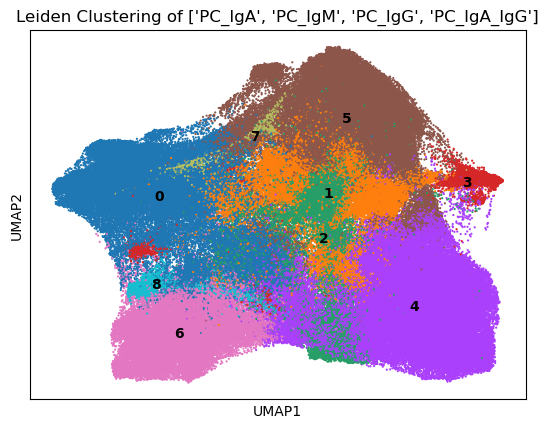

In [24]:
rsc.tl.leiden(sub, resolution=0.3, random_state=SEED_VALUE)

sc.pl.umap(
    sub, 
    color=["leiden"], 
    size=10, 
    legend_loc="on data", 
    frameon=True, 
    title=f"Leiden Clustering of {cts}"
)


Differential expression markers

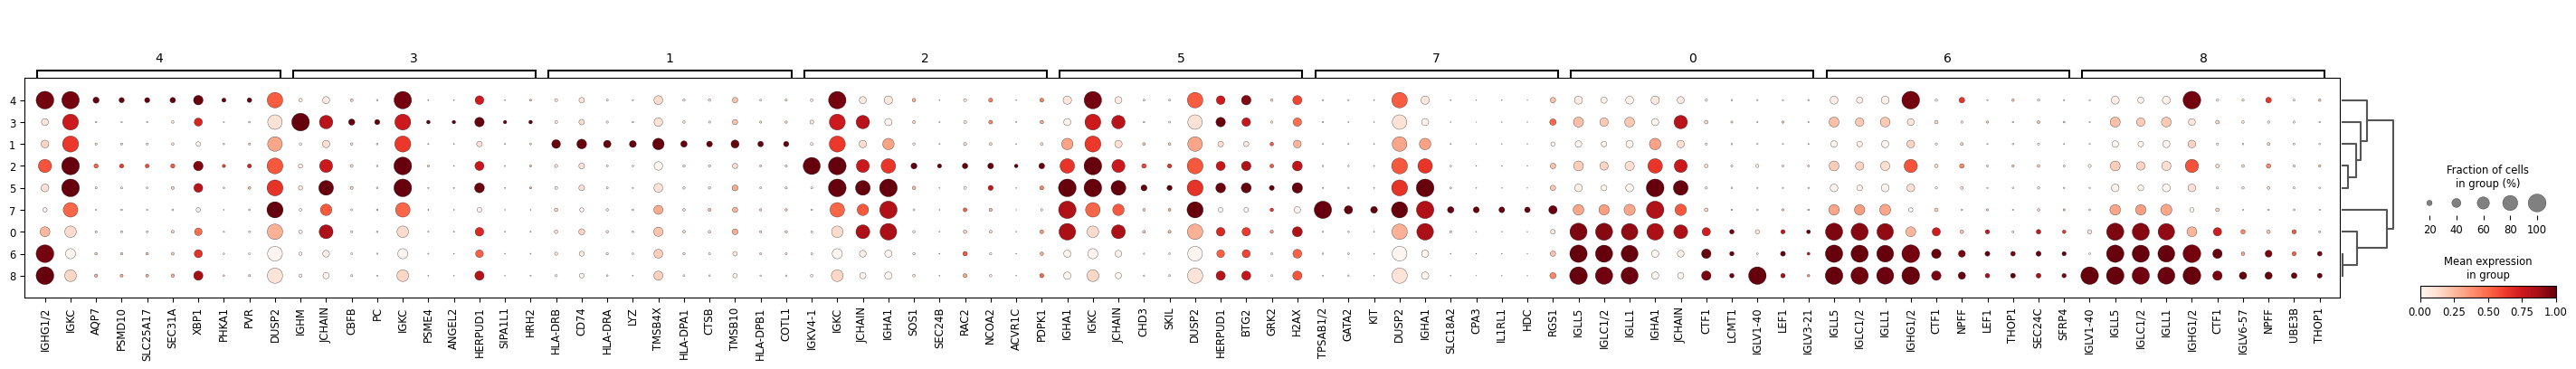

In [5]:
# get marker genes and dotplot

res_name = 'leiden'
layer_name = "resolvi_normalized"


rsc.tl.rank_genes_groups(
    sub, 
    groupby=res_name,
    method="wilcoxon",
)

sc.tl.dendrogram(
    sub, 
    groupby=res_name
)

# dotplot
dp = sc.pl.rank_genes_groups_dotplot(
    sub,
    groupby=res_name,
    #layer=layer_name,
    standard_scale="var",
    n_genes=10, # noramlly 5 
    show=False,
    return_fig=True,   # returns a DotPlot object
)

dp.show()


In [12]:
df = sc.get.rank_genes_groups_df(sub, group="2")
df.head()

#print(df.head(20).names.unique())

,names,scores,logfoldchanges,pvals,pvals_adj
0,IGKV4-1,191.808289,9.965234,0.0,0.0
1,IGKC,84.125923,2.817915,0.0,0.0
2,JCHAIN,39.077091,1.390666,0.0,0.0
3,IGHA1,37.508656,1.465548,0.0,0.0
4,SOS1,30.264008,1.838514,0.0,0.0


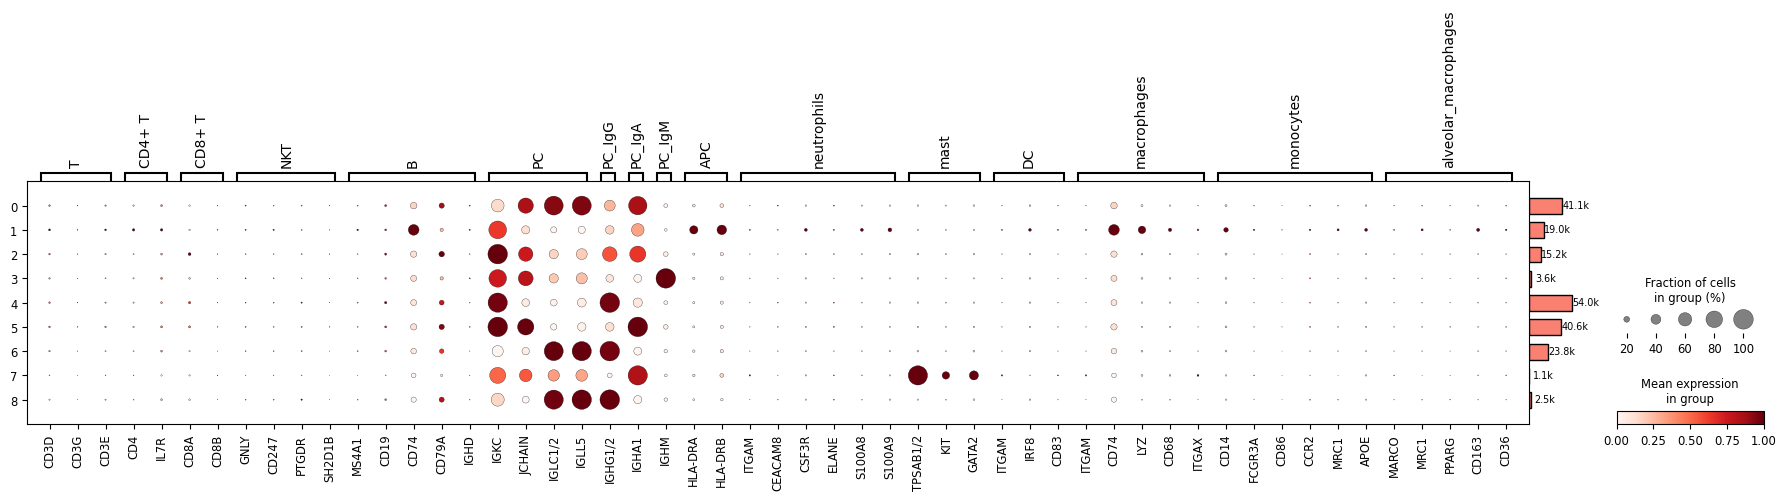

In [6]:
import json
# load canonical markers

all_markers_path = 'code/canonical_markers/immune_markers.json'
with open(all_markers_path, 'r') as f:
    all_markers = json.load(f)
# NOTE: check python file, some genes are suposed to be low/not expressed in some cell types


dp = sc.pl.dotplot(
        sub, 
        all_markers,
        #layer=layer_name, 
        #use_raw=False,
        groupby=res_name, 
        standard_scale='var', 
        return_fig=True
    )
# adding cell counts to the dotplot
dp.add_totals().show()


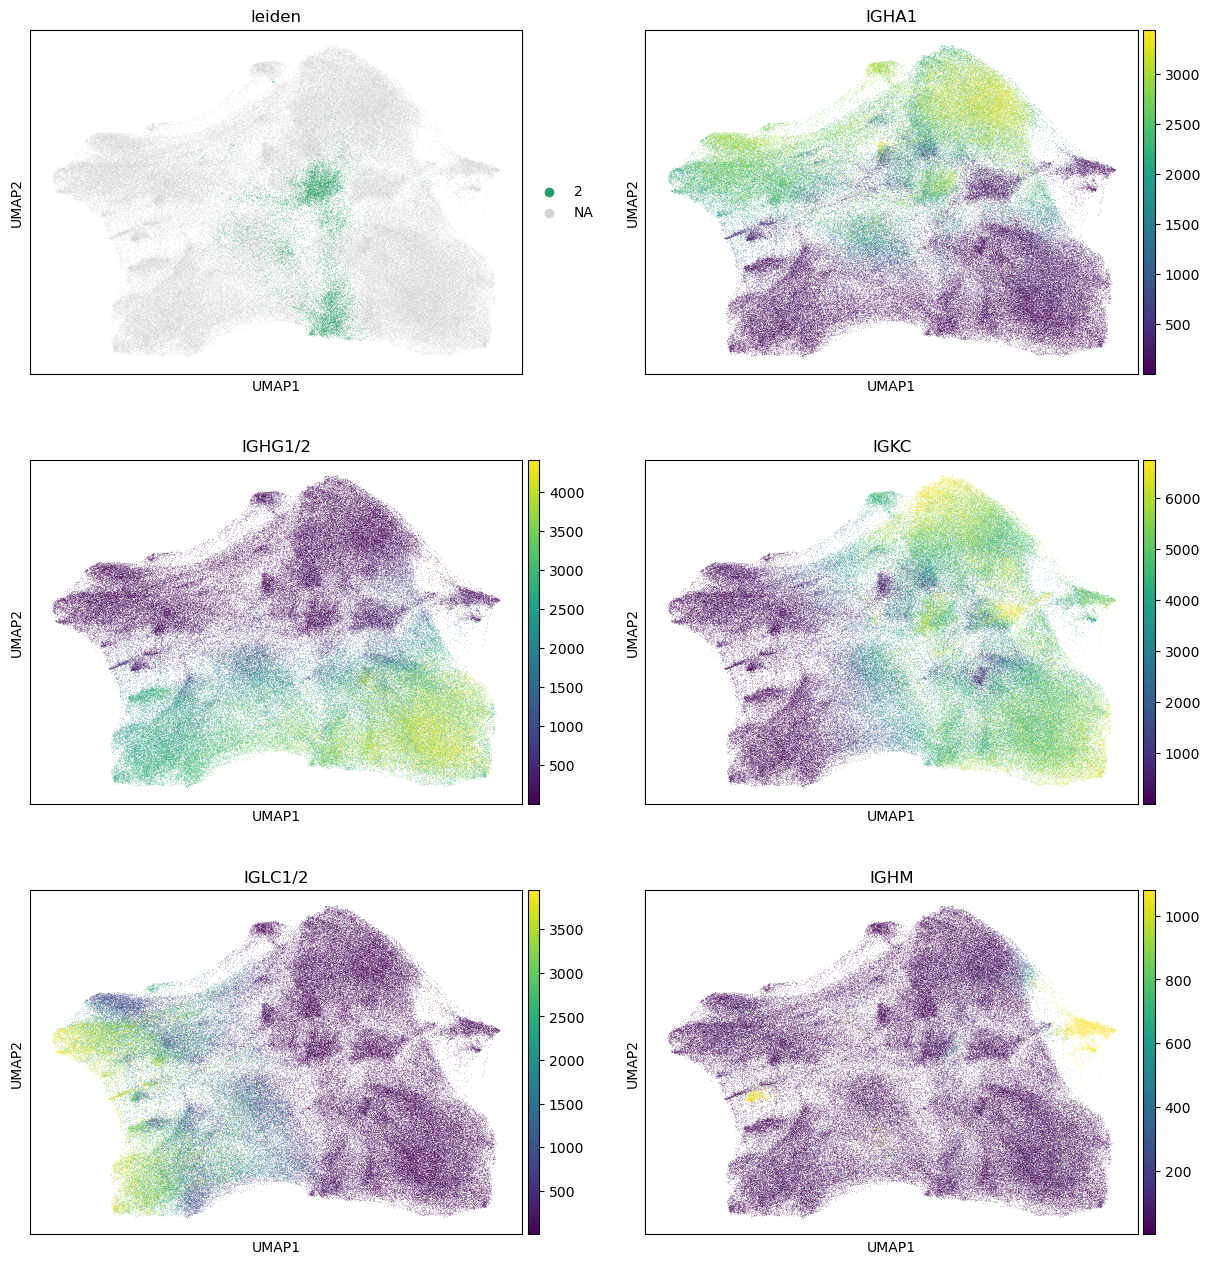

In [25]:
sc.pl.umap(
    sub,
    color=['leiden','IGHA1','IGHG1/2','IGKC','IGLC1/2','IGHM'],
    layer='resolvi_normalized',
    groups='2',
    vmax='p98',
    ncols=2
)

Check locations

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


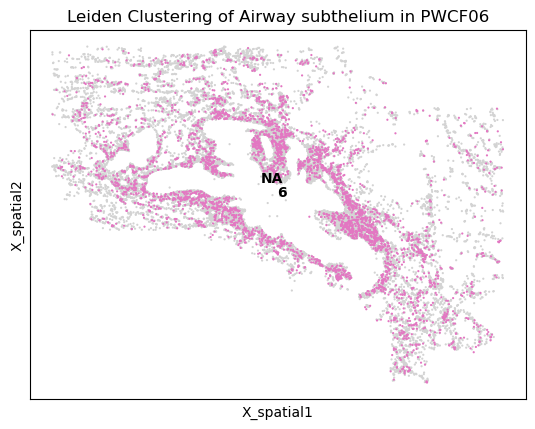

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


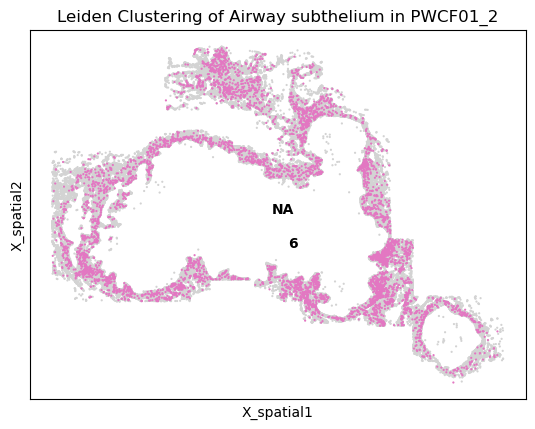

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


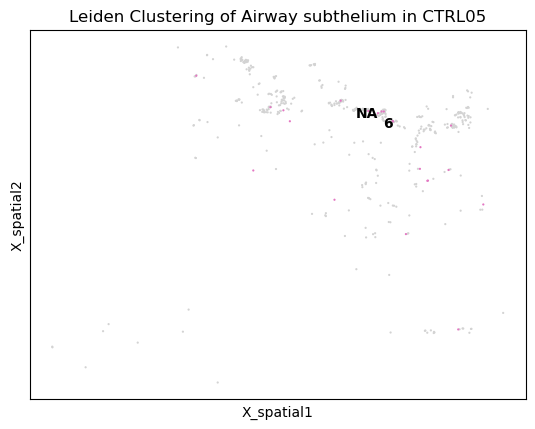

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


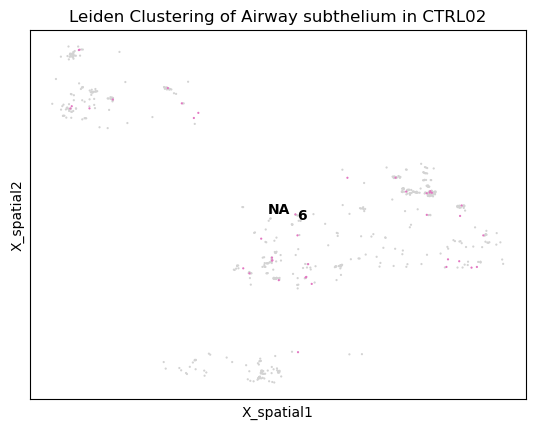

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


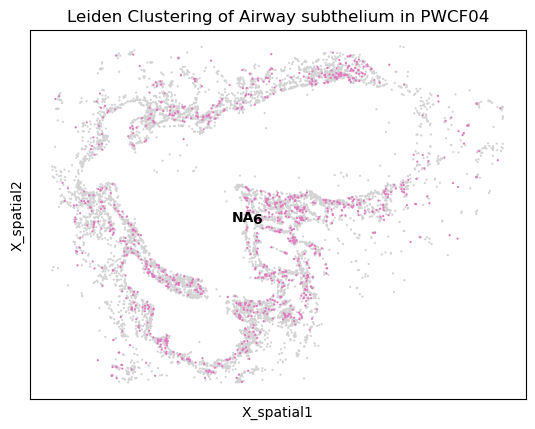

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


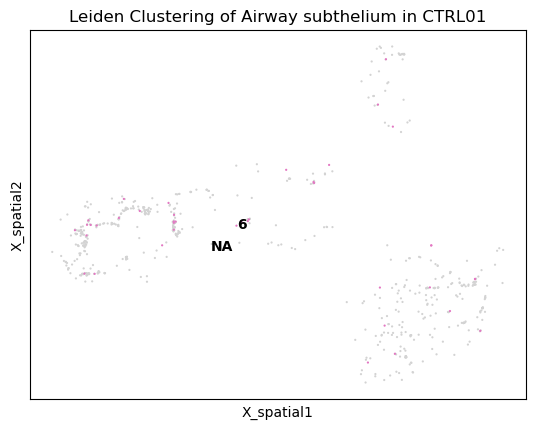

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


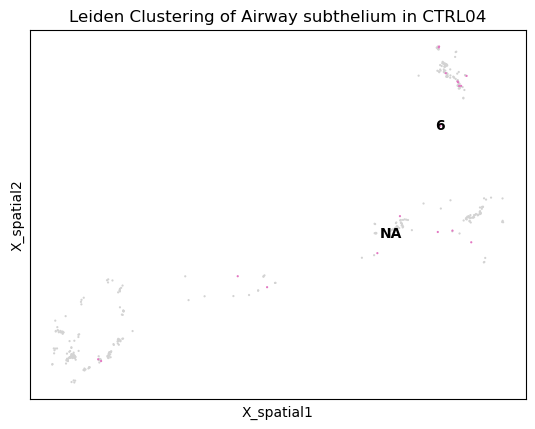

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


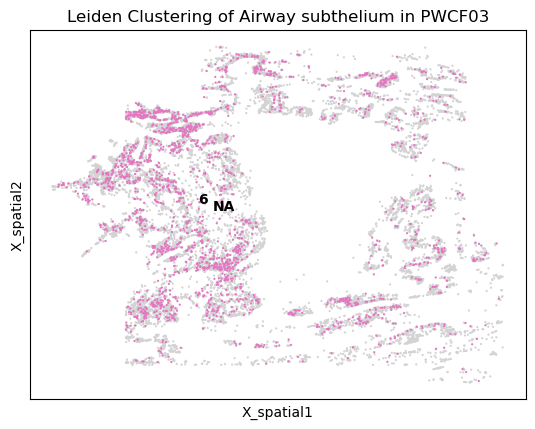

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


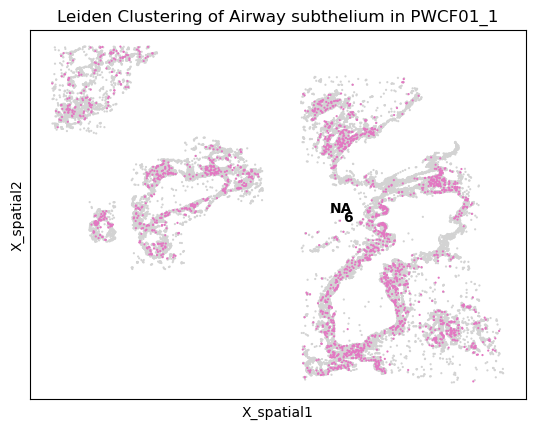

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


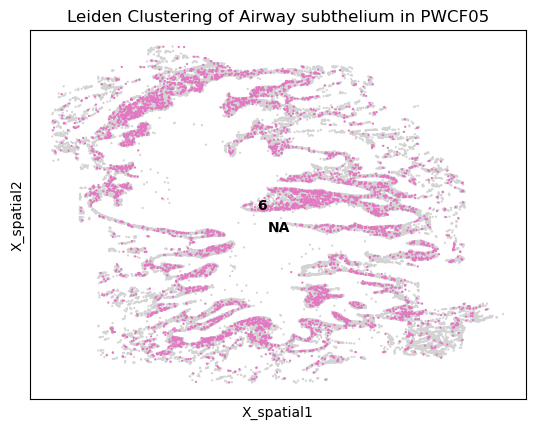

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


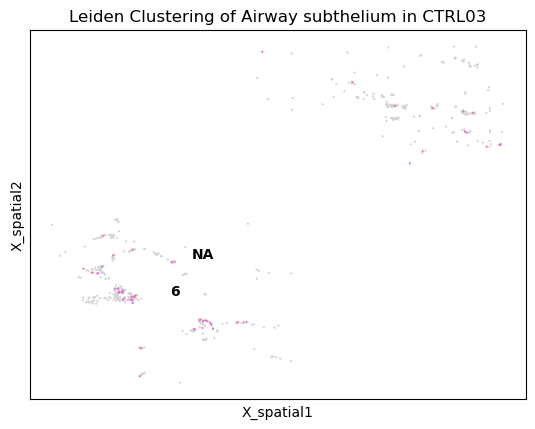

/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/scanpy/plotting/_utils.py:507: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


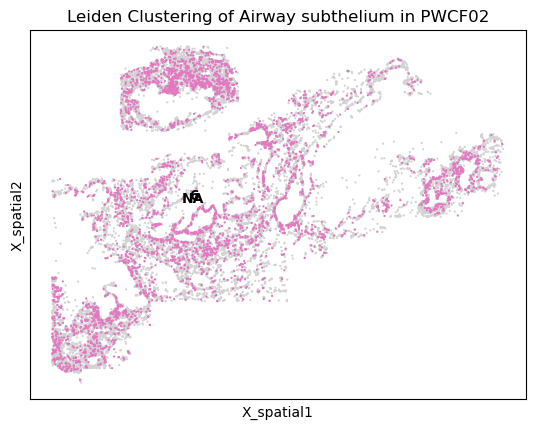

In [27]:
# print locations in PWCF01_1
samples = sub.obs['sample_name'].unique()

for sample in samples:
    mask = sub.obs['sample_name'] == sample

    sc.pl.embedding(
        sub[mask], 
        basis='X_spatial', 
        color='leiden', 
        groups=['6'], # fibroblasts
        size=10, 
        legend_loc="on data", 
        frameon=True, 
        title=f"Leiden Clustering of Plasma in {sample}"
    )

Name clusters

In [26]:
# K=kappa
# L=lambda

clusters_map = {
    "0": "PC_L_IgA", 
    "1": "Mac",
    "2": "PC_K_IgAG", # IGHA1 more predominant in DE markers, othewise expressing both IgA and IgG
    "3": "PC_K_IgM",
    "4": "PC_K_IgG",
    "5": "PC_K_IgA",
    "6": "PC_L_IgG",
    "7": "Mast",
    "8": "PC_L_IgG",
}
CT_KEY = 'reclustered_ct'
CLUSTERS_KEY = 'leiden'
sub.obs[CT_KEY] = sub.obs[CLUSTERS_KEY].map(clusters_map).astype('category')

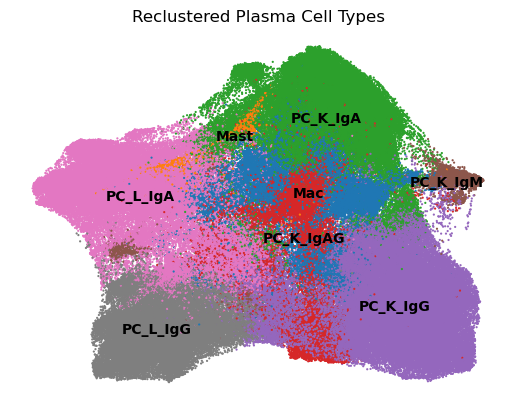

In [27]:
sc.pl.umap(
    sub, 
    color=[CT_KEY], 
    size=10, 
    legend_loc="on data", 
    frameon=False, 
    title="Reclustered Plasma Cell Types"
)

See how annotations changed

In [28]:
import pandas as pd
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

OLD_ANN_KEY = 'ann_lvl_3'
NEW_ANN_KEY = 'reclustered_ct'


# Keep only cells with both values
comparison = sub.obs[[OLD_ANN_KEY, NEW_ANN_KEY]].dropna().copy()

comparison[OLD_ANN_KEY] = comparison[OLD_ANN_KEY].astype(str)
comparison[NEW_ANN_KEY] = comparison[NEW_ANN_KEY].astype(str)

# -------------------------------------------------
# 1. Composition of every Leiden cluster
# -------------------------------------------------
counts = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
)

display(counts)

# Percentage composition within each Leiden cluster
percent_within_ann = pd.crosstab(
    comparison[OLD_ANN_KEY],
    comparison[NEW_ANN_KEY],
    normalize="index",
) * 100

display(percent_within_ann.round(1))

reclustered_ct,Mac,Mast,PC_K_IgA,PC_K_IgAG,PC_K_IgG,PC_K_IgM,PC_L_IgA,PC_L_IgG
ann_lvl_3,,,,,,,,
PC_IgA,10005,1135,37665,885,301,790,30038,270
PC_IgA_IgG,45,4,123,13367,1648,14,195,369
PC_IgG,2897,0,2659,898,51911,298,10821,25677
PC_IgM,6085,7,176,37,148,2520,47,1


reclustered_ct,Mac,Mast,PC_K_IgA,PC_K_IgAG,PC_K_IgG,PC_K_IgM,PC_L_IgA,PC_L_IgG
ann_lvl_3,,,,,,,,
PC_IgA,12.3,1.4,46.4,1.1,0.4,1.0,37.0,0.3
PC_IgA_IgG,0.3,0.0,0.8,84.8,10.5,0.1,1.2,2.3
PC_IgG,3.0,0.0,2.8,0.9,54.6,0.3,11.4,27.0
PC_IgM,67.5,0.1,2.0,0.4,1.6,27.9,0.5,0.0


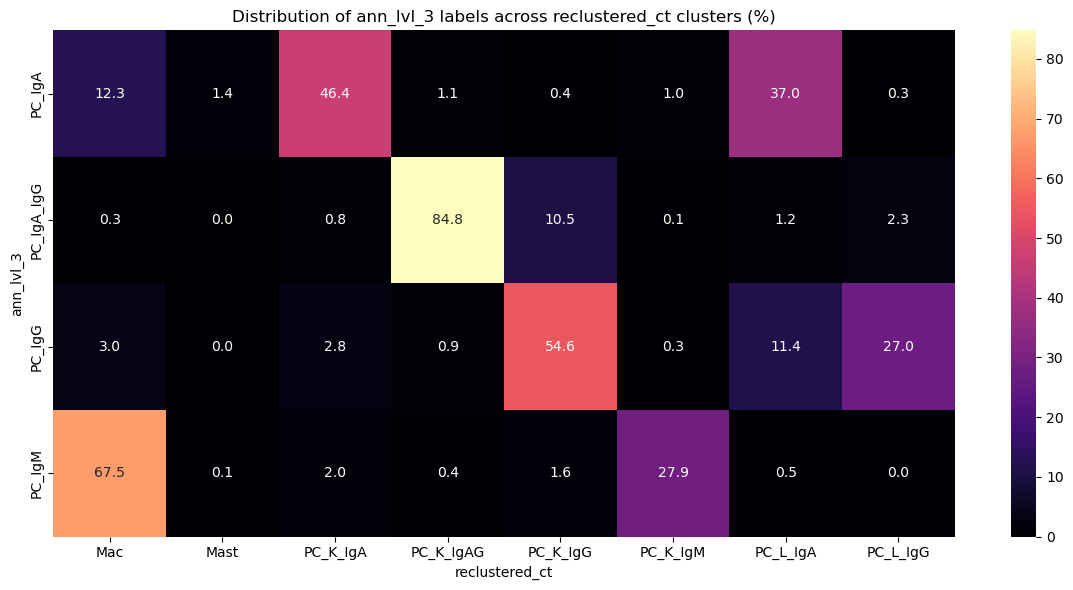

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(percent_within_ann, cmap="magma", annot=True, fmt=".1f")
plt.xlabel(NEW_ANN_KEY)
plt.ylabel(OLD_ANN_KEY)
plt.title(f"Distribution of {OLD_ANN_KEY} labels across {NEW_ANN_KEY} clusters (%)")
plt.tight_layout()
plt.show()

Save annotated object

In [9]:
sub.obs[['reclustered_ct','condition']].value_counts()

reclustered_ct  condition
PC_K_IgG        CF           46390
PC_K_IgA        CF           36227
PC_L_IgA        CF           35218
PC_L_IgG        CF           20789
Mac             CF           14929
PC_K_IgAG       CF           13653
PC_K_IgG        CF_ETI        7272
PC_L_IgG        CF_ETI        5329
PC_L_IgA        CF_ETI        5140
PC_K_IgA        CF_ETI        3885
Mac             CF_ETI        3626
PC_K_IgM        CF            3085
PC_K_IgAG       CF_ETI        1436
Mast            CF             980
PC_L_IgA        CTRL           743
PC_K_IgA        CTRL           511
Mac             CTRL           477
PC_K_IgM        CF_ETI         347
PC_K_IgG        CTRL           346
PC_L_IgG        CTRL           199
PC_K_IgM        CTRL           190
Mast            CF_ETI         149
PC_K_IgAG       CTRL            98
Mast            CTRL            17
Name: count, dtype: int64

In [32]:
# create the parent folder of the new object path if it doesn't exist
NEW_OBJ_PATH.parent.mkdir(parents=True, exist_ok=True)

In [30]:
sub.write_h5ad(NEW_OBJ_PATH)